### Long-range CNOT gate teleportation using dynamic circuits

#### Step 1: Map the problem to circuit and operators

In [61]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr

def get_dynamic_CNOT_circuit(num_qubit, num_ancilla=None, num_ancilla_pair=None):
    """
    (1) 1D chain of nearest-neighbors
    (2) 0th qubit is the control and last qubit (num_qubit-1) is the target
    (3) The control qubit starts in the + state
    """
    if num_ancilla is None:
        num_ancilla = num_qubit - 2
    if num_ancilla_pair is None:
        num_ancilla_pair = num_ancilla // 2
    
    qr = QuantumRegister(num_qubit)
    cr1 = ClassicalRegister(num_ancilla_pair, name="cr1") # The parity-controlled X gate
    cr2 = ClassicalRegister(num_ancilla - num_ancilla_pair, name="cr2") # The parity-controlled Z gate
    cr3 = ClassicalRegister(2, name="cr3") # The final measurement on the control and target qubits
    qc = QuantumCircuit(qr, cr1, cr2, cr3)

    # Initialize the control qubit
    qc.h(0)
    qc.barrier()

    # Entangle the control qubit and the ancilla qubit
    qc.cx(0, 1)

    # Create Bell pairs between ancilla qubit
    # The first ancilla qubit in index 1
    for i in range (num_ancilla_pair):
        qc.h(2 + 2*i )
        qc.cx(2 + 2*i, 2 + 2*i + 1)

    # Prepare Bell pairs on the staggered and data qubits
    for i in range(num_ancilla_pair+1):
        qc.cx(1 + 2*i, 1 + 2*i+1)
    for i in range(1, num_ancilla_pair+2): 
        qc.h(2*i-1)   

    # Measurement of the ancilla qubits starting with the first one 
    # Keep track of the parity of the measurement results for eventual conditional Z gate
    for i in range(1, num_ancilla_pair+2):
        qc.measure(2*i - 1, cr2[i-1])
        if i == 1:
            parity_control = expr.lift(cr2[i-1])
        else:
            parity_control = expr.bit_xor(cr2[i-1], parity_control)

    # Measurement of the ancilla qubits starting with the second one
    # Keep track of the parity of the measurement results for eventual conditional X gate
    for i in range(num_ancilla_pair):
        qc.measure(2 + 2*i, cr1[i])
        if i == 0:
            parity_target = expr.lift(cr1[i])
        else:
            parity_target = expr.bit_xor(cr1[i], parity_target)

    with qc.if_test(parity_control):
        qc.z(0)

    with qc.if_test(parity_target):
        qc.x(-1)

    # ---- ADD THIS ----
    qc.measure(0, cr3[0])
    qc.measure(num_qubit - 1, cr3[1])
    # ------------------

    return qc


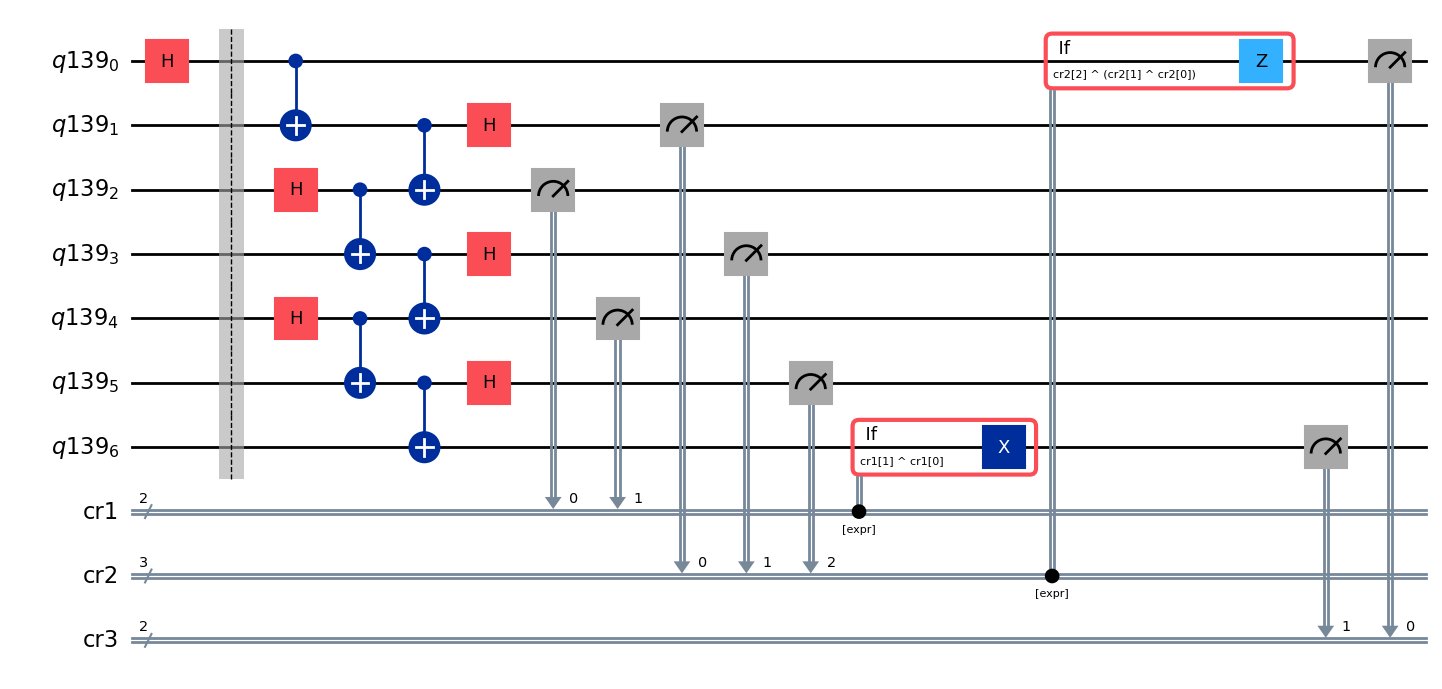

In [62]:
qc = get_dynamic_CNOT_circuit(num_qubit=7)
qc.draw(output='mpl')

In [69]:
max_num_qubit = 80

qc_list = []
num_qubit_list = list(range(7, max_num_qubit+1, 2))
for num_qubit in num_qubit_list:
    qc = get_dynamic_CNOT_circuit(num_qubit = num_qubit)
    qc_list.append(qc)

#### Step 2: Optimize the problem for quantum execution 

In [70]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

backend_name = "ibm_marrakesh"
service = QiskitRuntimeService()
backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)

qc_transpiled_list = pass_manager.run(qc_list)

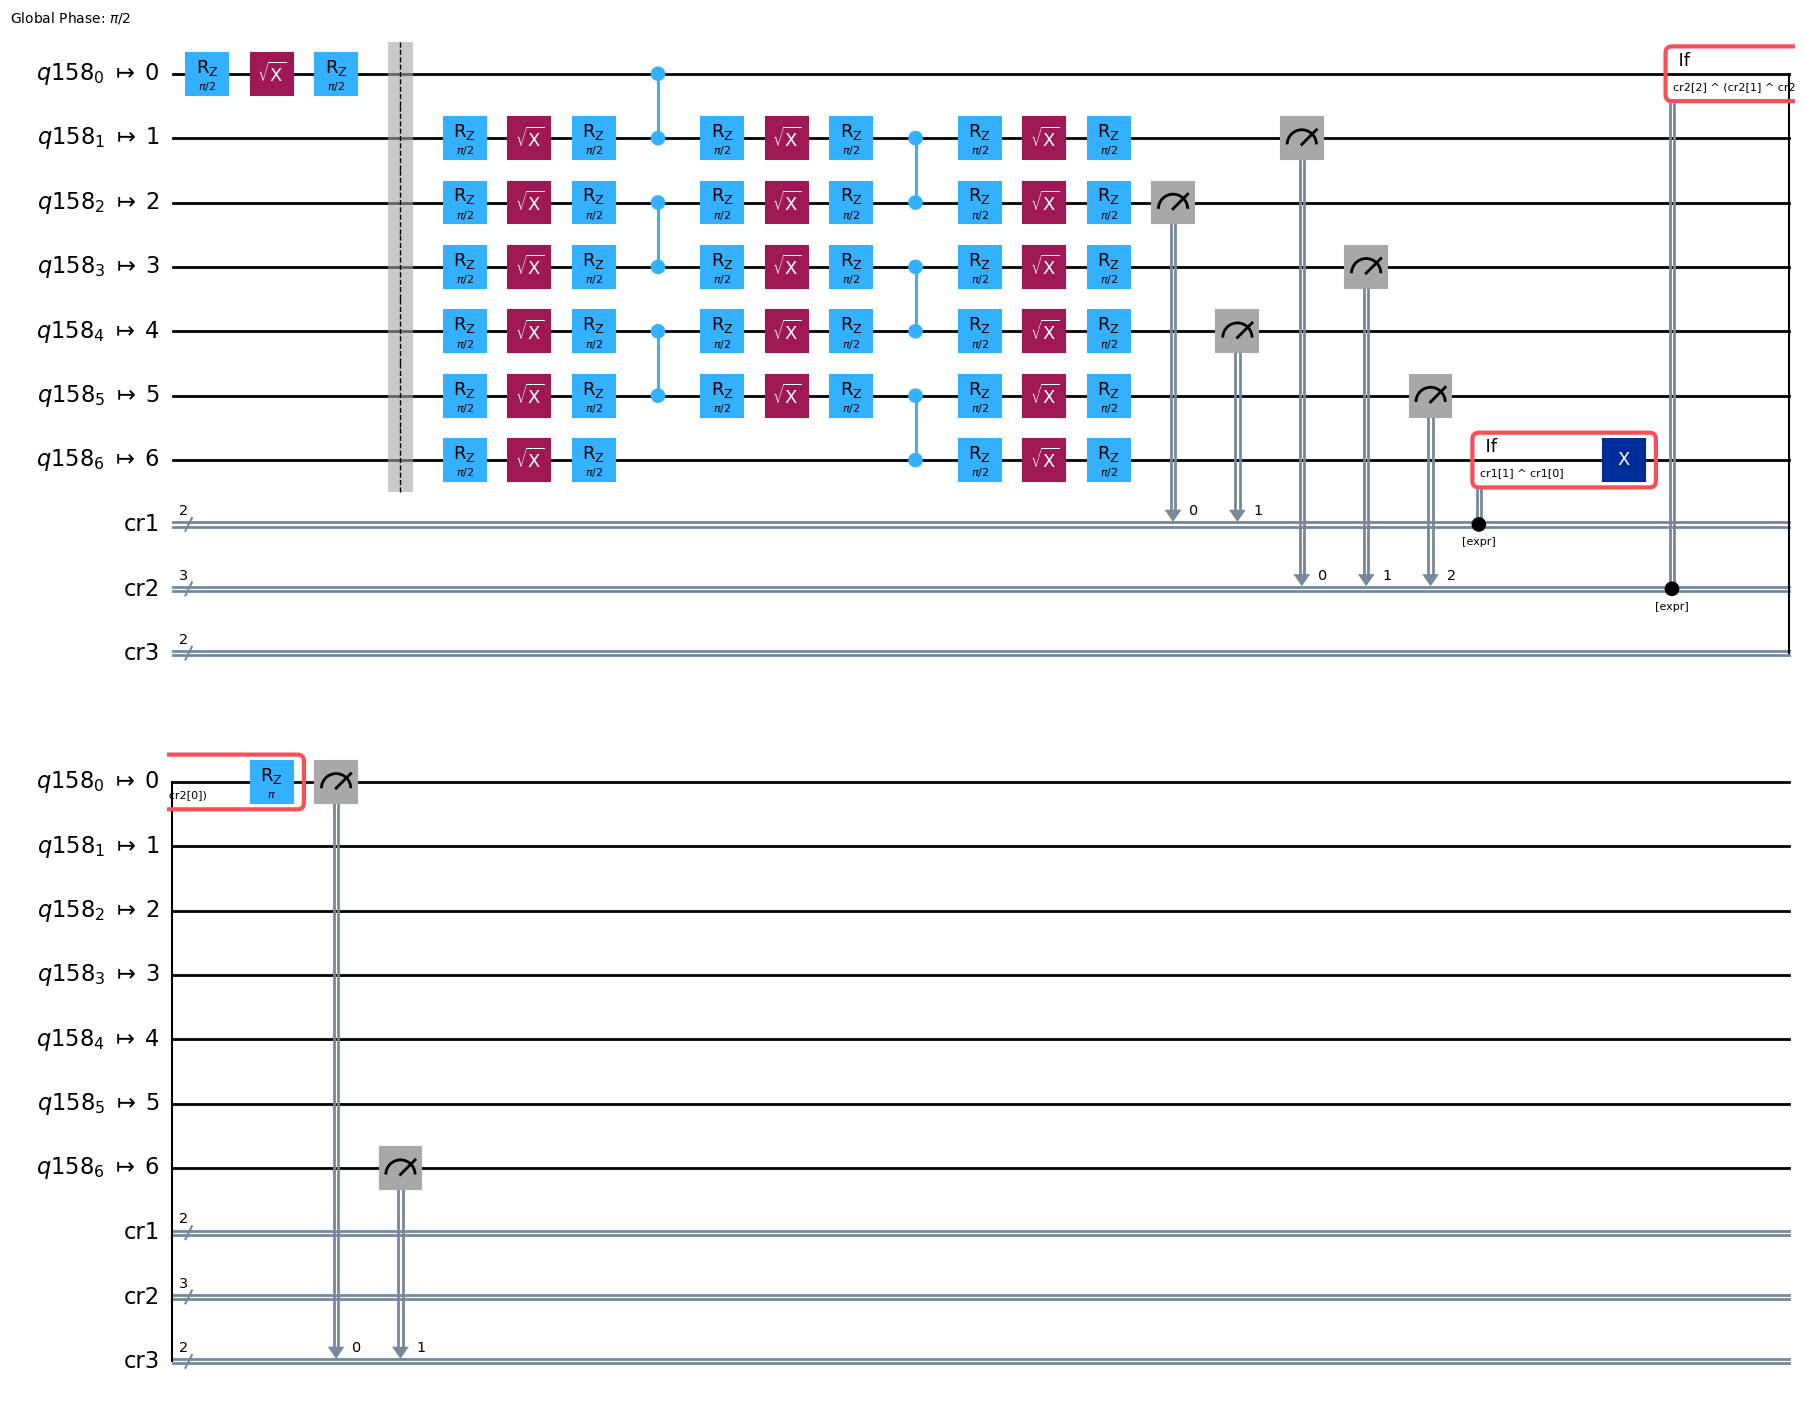

In [71]:
qc_transpiled_list[0].draw(output='mpl')

#### Step 3: Execute the circuit

In [72]:
from qiskit_ibm_runtime import Sampler
sampler = Sampler(backend)
job = sampler.run(qc_transpiled_list)
print (job.job_id())

d5rrjlbv0pgs73920pm0


#### Step 4: Post-processing and plotting

In [ ]:
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService

job_id = 'd5rrjlbv0pgs73920pm0'

service = QiskitRuntimeService()
job = service.job(job_id)
result = job.result()

list_Bell = []
list_other = []

# Align results explicitly with qubit list
for res in result[:len(num_qubit_list)]:
    data = res.data
    counts = data.cr3.get_counts()

    total_counts = sum(counts.values())   # always correct

    prob_Bell = (
        counts.get('00', 0) + counts.get('11', 0)
    ) / total_counts if total_counts > 0 else 0.0

    list_Bell.append(prob_Bell)
    list_other.append(1.0 - prob_Bell)

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.plot(num_qubit_list, list_Bell, 'o-', label='|00⟩ + |11⟩ (Bell population)')
plt.plot(num_qubit_list, list_other, 's--', label='Other states')

plt.xlabel('Number of qubits')
plt.ylabel('Probability')
plt.title('Dynamic CNOT Circuit Results on IBM Torino')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
